Saving data-en-hi-de-fr.csv to data-en-hi-de-fr (5).csv
CHARGEMENT DES DONNÉES
  label                                            message
0   ham  Allez jusqu'à Jurong point, fou.. Disponible s...
1   ham           J'ai fait une blague sur le wif u oni...
2  spam  Entrée libre dans 2 a wkly comp pour gagner FA...
3   ham     U dun dit si tôt hor... U c déjà dire alors...
4   ham  Non, je ne pense pas qu'il va à usf, il vit da...
(5572, 2)
Spam (1): 0
Normal (0): 0

Accuracy: 0.9883408071748879

Rapport de classification:
              precision    recall  f1-score   support

      Normal     0.9877    0.9990    0.9933       966
        Spam     0.9928    0.9195    0.9547       149

    accuracy                         0.9883      1115
   macro avg     0.9902    0.9592    0.9740      1115
weighted avg     0.9884    0.9883    0.9882      1115



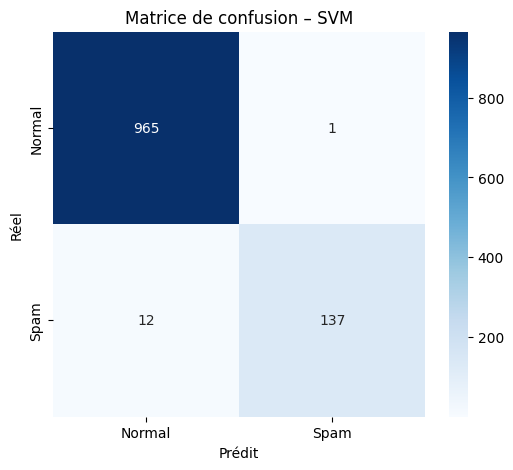


✅ Modèle et vectorizer sauvegardés

INTERFACE DE TEST DU MODÈLE (SVM + TF-IDF)
Tape 'exit' pour quitter

✉️ Entrez un message à tester : Gagnez 5000€ maintenant cliquez ici
🚨 RÉSULTAT : SPAM
📊 Probabilités → Normal: 0.323 | Spam: 0.677

✉️ Entrez un message à tester : Salut, on se voit demain ?
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.998 | Spam: 0.002

✉️ Entrez un message à tester : Bonjour, j'aimerais entrer en contact avec toi.
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.972 | Spam: 0.028

✉️ Entrez un message à tester : Vous avez gagnez 2000$ à la loterie!
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.810 | Spam: 0.190

✉️ Entrez un message à tester : Vous avez gagnez 2000€ à la loterie!
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.810 | Spam: 0.190

✉️ Entrez un message à tester : Vous avez gagner 2000€ à la loterie, veillez nous contacter
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.729 | Spam: 0.271

✉️ Entrez un message à 

KeyboardInterrupt: Interrupted by user

In [29]:
# ========================================
# IMPORTS
# ========================================
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from google.colab import files

# ========================================
# CHARGEMENT DU DATASET
# ========================================
files.upload()

df = pd.read_csv("data-en-hi-de-fr.csv")

# Garder uniquement le français
df = df[["labels", "text_fr"]]

# Renommer les colonnes
df = df.rename(columns={
    "labels": "label",
    "text_fr": "message"
})

df = df.dropna().reset_index(drop=True)

print("="*60)
print("CHARGEMENT DES DONNÉES")
print("="*60)
print(df.head())
print(df.shape)
print(f"Spam (1): {(df['label']==1).sum()}")
print(f"Normal (0): {(df['label']==0).sum()}")

# ========================================
# PRÉ-TRAITEMENT DU TEXTE
# ========================================
def nettoyer_texte(texte):
    texte = re.sub(r'http\S+|www\.\S+', '', texte)
    texte = re.sub(r'\S+@\S+', '', texte)
    texte = re.sub(r'\s+', ' ', texte)
    return texte.strip()

def tokeniser(texte):
    texte = texte.lower()
    return re.findall(r'\b\w+\b', texte)

stopwords_fr = {
    'le','la','les','un','une','des','du','de','et','ou','mais','donc','or','ni','car',
    'ce','ces','cette','cet','est','sont','a','ont','être','avoir','fait','faire',
    'je','tu','il','elle','nous','vous','ils','elles','mon','ton','son','ma','ta','sa',
    'mes','tes','ses','dans','sur','avec','sans','pour','par','en'
}

def supprimer_stopwords(tokens):
    return [t for t in tokens if t not in stopwords_fr and len(t) > 1]

def normaliser(tokens):
    return [t.strip(string.punctuation) for t in tokens if t.strip(string.punctuation)]

# Application du pipeline
df['texte_final'] = df['message'].apply(
    lambda x: " ".join(
        normaliser(
            supprimer_stopwords(
                tokeniser(
                    nettoyer_texte(x)
                )
            )
        )
    )
)

# ========================================
# TF-IDF
# ========================================
X = df['texte_final']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ========================================
# MODÈLE SVM
# ========================================
svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

# ========================================
# ÉVALUATION
# ========================================
y_pred = svm_model.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nRapport de classification:")
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Spam"],
    digits=4
))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Normal", "Spam"],
    yticklabels=["Normal", "Spam"],
    cmap="Blues"
)
plt.title("Matrice de confusion – SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# ========================================
# SAUVEGARDE
# ========================================
joblib.dump(svm_model, "svm_spam_model_fr.pkl")
joblib.dump(tfidf, "tfidf_fr.pkl")

print("\n✅ Modèle et vectorizer sauvegardés")

# ========================================
# INTERFACE DE TEST INTERACTIVE
# ========================================
print("\n" + "="*60)
print("INTERFACE DE TEST DU MODÈLE (SVM + TF-IDF)")
print("Tape 'exit' pour quitter")
print("="*60)

SEUIL_SPAM = 0.5  # seuil probabiliste

while True:
    message = input("\n✉️ Entrez un message à tester : ")

    if message.lower() == "exit":
        print("\n👋 Fin du test")
        break

    # --- PRÉ-TRAITEMENT OBLIGATOIRE ---
    t = nettoyer_texte(message)
    t = tokeniser(t)
    t = supprimer_stopwords(t)
    t = normaliser(t)
    t = " ".join(t)

    # Vectorisation
    vecteur = tfidf.transform([t])

    # Probabilités
    probabilites = svm_model.predict_proba(vecteur)[0]

    # Décision basée sur la probabilité
    if probabilites[1] >= SEUIL_SPAM:
        print("🚨 RÉSULTAT : SPAM")
    else:
        print("✅ RÉSULTAT : MESSAGE NORMAL")

    print(f"📊 Probabilités → Normal: {probabilites[0]:.3f} | Spam: {probabilites[1]:.3f}")


Saving data-en-hi-de-fr.csv to data-en-hi-de-fr (8).csv
CHARGEMENT DES DONNÉES
  label                                            message
0   ham  Allez jusqu'à Jurong point, fou.. Disponible s...
1   ham           J'ai fait une blague sur le wif u oni...
2  spam  Entrée libre dans 2 a wkly comp pour gagner FA...
3   ham     U dun dit si tôt hor... U c déjà dire alors...
4   ham  Non, je ne pense pas qu'il va à usf, il vit da...
(5572, 2)
Spam (1): 0
Normal (0): 0

Accuracy : 0.9883408071748879

Rapport de classification :

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       966
        Spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



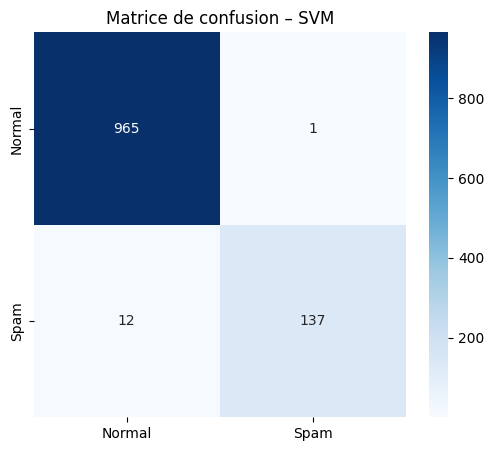


✅ Architecture SVM + TF-IDF sauvegardée
✅ Architecture PKL chargée

INTERFACE DE TEST SVM (PKL)
Tapez 'exit' pour quitter

✉️ Entrez un message à tester : URGENT votre compte bancaire sera bloqué cliquez ici
🚨 RÉSULTAT : SPAM
📊 Probabilités → Normal: 0.469 | Spam: 0.531

✉️ Entrez un message à tester : bonjour
✅ RÉSULTAT : MESSAGE NORMAL
📊 Probabilités → Normal: 0.983 | Spam: 0.017


KeyboardInterrupt: Interrupted by user

In [33]:
# ========================================
# IMPORTS
# ========================================
import pandas as pd
import re
import string
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from google.colab import files

# ========================================
# CHARGEMENT DU DATASET
# ========================================
files.upload()

df = pd.read_csv("data-en-hi-de-fr.csv")

df = df[["labels", "text_fr"]].rename(columns={
    "labels": "label",
    "text_fr": "message"
})

df = df.dropna().reset_index(drop=True)

print("="*60)
print("CHARGEMENT DES DONNÉES")
print("="*60)
print(df.head())
print(df.shape)
print(f"Spam (1): {(df['label']==1).sum()}")
print(f"Normal (0): {(df['label']==0).sum()}")

# ========================================
# PRÉ-TRAITEMENT NLP
# ========================================
def nettoyer_texte(texte):
    texte = re.sub(r'http\S+|www\.\S+', '', texte)
    texte = re.sub(r'\S+@\S+', '', texte)
    texte = re.sub(r'\s+', ' ', texte)
    return texte.strip()

def tokeniser(texte):
    return re.findall(r'\b\w+\b', texte.lower())

stopwords_fr = {
    'le','la','les','un','une','des','du','de','et','ou','mais','donc','or','ni','car',
    'ce','ces','cette','cet','est','sont','a','ont','être','avoir','fait','faire',
    'je','tu','il','elle','nous','vous','ils','elles','mon','ton','son','ma','ta','sa',
    'mes','tes','ses','dans','sur','avec','sans','pour','par','en'
}

def supprimer_stopwords(tokens):
    return [t for t in tokens if t not in stopwords_fr and len(t) > 1]

def normaliser(tokens):
    return [t.strip(string.punctuation) for t in tokens if t.strip(string.punctuation)]

df["texte_final"] = df["message"].apply(
    lambda x: " ".join(
        normaliser(
            supprimer_stopwords(
                tokeniser(
                    nettoyer_texte(x)
                )
            )
        )
    )
)

# ========================================
# TF-IDF
# ========================================
X = df["texte_final"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ========================================
# ENTRAÎNEMENT SVM
# ========================================
svm_model = SVC(kernel="linear", probability=True, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=["Normal", "Spam"]))

# ========================================
# MATRICE DE CONFUSION
# ========================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal", "Spam"],
            yticklabels=["Normal", "Spam"],
            cmap="Blues")
plt.title("Matrice de confusion – SVM")
plt.show()

# ========================================
# SAUVEGARDE PKL
# ========================================
joblib.dump(svm_model, "svm_spam_model_fr.pkl")
joblib.dump(tfidf, "tfidf_fr.pkl")

print("\n✅ Architecture SVM + TF-IDF sauvegardée")

# ========================================
# CHARGEMENT PKL
# ========================================
svm_model = joblib.load("svm_spam_model_fr.pkl")
tfidf = joblib.load("tfidf_fr.pkl")

print("✅ Architecture PKL chargée")

# ========================================
# PIPELINE DE PRÉDICTION
# ========================================
def predire_spam(message):
    t = nettoyer_texte(message)
    t = tokeniser(t)
    t = supprimer_stopwords(t)
    t = normaliser(t)
    t = " ".join(t)

    vec = tfidf.transform([t])
    pred = svm_model.predict(vec)[0]
    proba = svm_model.predict_proba(vec)[0]

    return pred, proba

# ========================================
# INTERFACE DE TEST
# ========================================
SEUIL_SPAM = 0.5

print("\n" + "="*60)
print("INTERFACE DE TEST SVM (PKL)")
print("Tapez 'exit' pour quitter")
print("="*60)

while True:
    msg = input("\n✉️ Entrez un message à tester : ")

    if msg.lower() == "exit":
        print("\n👋 Fin du test")
        break

    pred, proba = predire_spam(msg)

    if proba[1] >= SEUIL_SPAM:
        print("🚨 RÉSULTAT : SPAM")
    else:
        print("✅ RÉSULTAT : MESSAGE NORMAL")

    print(f"📊 Probabilités → Normal: {proba[0]:.3f} | Spam: {proba[1]:.3f}")
